# Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras.losses import MeanSquaredError

import sys
sys.path.append('..')
from pipeline import (
    filter_port,
)

# Load and preview distribution

In [2]:
df_raw = pd.read_csv("../ryu-controller/traffic_log.csv")

# Keep only normal traffic
df = df_raw[df_raw["Traffic"] == "Normal"].copy()

print(f"Total normal rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print()
print("Protocol breakdown (raw):")
print(df["Ip_protocole"].value_counts())

Total normal rows: 75221
Columns: ['Timestamp', 'Ip_src', 'Ip_dst', 'Same_ip', 'Port_src', 'Port_dst', 'Ip_protocole', 'Type_protocole', 'Icmp', 'Icmp_code', 'Icmp_type', 'Tcp', 'Udp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Dns', 'Flow_duration', 'Flow_dur_nsec', 'Packet_count', 'Bytes', 'Pkt_per_sec', 'Pkt_per_nsec', 'Bytes_per_sec', 'Bytes_per_nsec', 'Traffic', 'Attack_type']

Protocol breakdown (raw):
Ip_protocole
tcp     46091
udp     16230
icmp    12900
Name: count, dtype: int64


# Engineered Features: got them from classifiers

In [3]:
df['Duration_per_packet'] = df['Flow_duration'] / (df['Packet_count'] + 1e-6)
df['Avg_pkt_size'] = (
    df['Bytes_per_sec'] / (df['Pkt_per_sec'] + 1e-6)
).replace([np.inf, -np.inf], 0)

print("Engineered features added.")
print(df[['Duration_per_packet', 'Avg_pkt_size']].describe())

Engineered features added.
       Duration_per_packet  Avg_pkt_size
count         7.522100e+04  75221.000000
mean          1.865539e+07     29.738120
std           1.981340e+07     41.078098
min           0.000000e+00      0.000000
25%           1.600000e+01      0.000000
50%           1.200000e+07      0.000000
75%           3.600000e+07     65.999406
max           6.000000e+07    413.996688


# NA value handling

Filling rows with NaN with meaningful sentinel values:

- Binary / flag columns -> `0`  (absence of feature)
- ICMP-specific columns -> `-1` (not applicable for non-ICMP flows)
- Port columns          -> `0`  (unknown / no port)

In [4]:
FLAG_COLS = ["Tcp","Ftp","Icmp","Dns","Port_dst","Udp","Smtp",
             "Http","SYN","ACK","FIN","PSH","RST"]
ICMP_COLS = ["Icmp_code","Icmp_type"]

for col in FLAG_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0)

for col in ICMP_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(-1)

print("Remaining NaNs per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining NaNs per column:
Type_protocole    15608
Attack_type       75221
dtype: int64


# Protocol distribution before augmentation

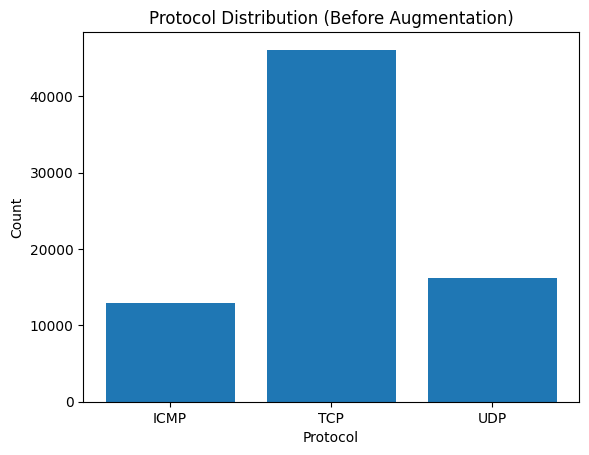

{'ICMP': 12900, 'TCP': 46091, 'UDP': 16230}


In [5]:
counts = {
    "ICMP": len(df[df["Ip_protocole"] == "icmp"]),
    "TCP":  len(df[df["Ip_protocole"] == "tcp"]),
    "UDP":  len(df[df["Ip_protocole"] == "udp"]),
}

plt.figure()
plt.bar(counts.keys(), counts.values())
plt.title("Protocol Distribution (Before Augmentation)")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()
print(counts)

# Balancing dataset via Mixup augmentation

In [7]:
MIX_COLS = ["Packet_count", "Bytes", "Pkt_per_sec",
 "Bytes_per_sec", "Bytes_per_nsec"]

def mixup_protocol(df_full, proto_col_flag):
    """Create synthetic samples for an under-represented protocol via MixUp."""
    sub = df_full[df_full[proto_col_flag] == 1].copy().reset_index(drop=True)
    df1 = sub.sample(frac=1, random_state=42).reset_index(drop=True)
    df2 = sub.sample(frac=1, random_state=0).reset_index(drop=True)
    lam = np.random.uniform(0.3, 0.7)
    mixed = df1.copy()
    for col in MIX_COLS:
        if col in mixed.columns:
            mixed[col] = lam * df1[col] + (1 - lam) * df2[col]
    return mixed

In [8]:
df_aug = df.copy()

# Augment ICMP (the under represented protocol, that is driving me nuts)
df_aug = pd.concat([df_aug, mixup_protocol(df, "Icmp")], ignore_index=True)

# Augment UDP (also under-represented, but less so than ICMP)
df_aug = pd.concat([df_aug, mixup_protocol(df, "Udp")], ignore_index=True)

In [9]:
counts_aug = {
    "ICMP": df_aug["Icmp"].sum(),
    "TCP":  df_aug["Tcp"].sum(),
    "UDP":  df_aug["Udp"].sum(),
}
counts_aug

{'ICMP': np.int64(25800), 'TCP': np.int64(46091), 'UDP': np.int64(32460)}

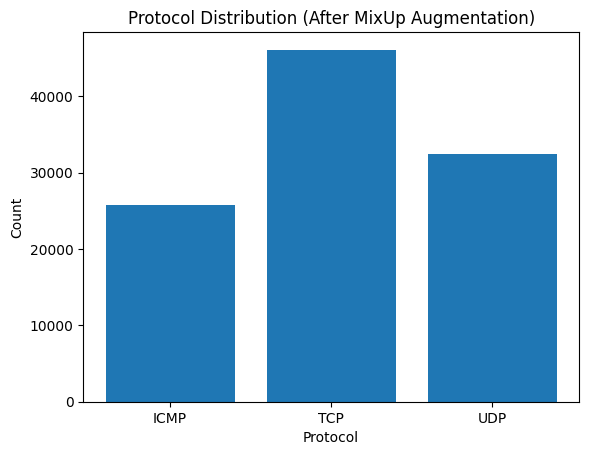

{'ICMP': np.int64(25800), 'TCP': np.int64(46091), 'UDP': np.int64(32460)}


In [10]:
plt.figure()
plt.bar(counts_aug.keys(), counts_aug.values())
plt.title("Protocol Distribution (After MixUp Augmentation)")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()
print(counts_aug)

# Feature selection via Pearson Correlation Matrix

> Something I learned 👍

Pearson correlation measures the linear relationship between two columns.
Values close to +1 or -1 mean the two columns carry nearly identical information.
Keeping both is redundant, it adds noise without adding signal for the autoencoder.

**How to read the heatmap:**
- Each cell shows `corr(col_A, col_B)`
- Red/bright = high positive correlation -> consider dropping one
- Blue/dark   = high negative correlation -> also redundant
- Rule of thumb: if `|r| > 0.90`, drop the less interpretable of the pair

After inspecting the heatmap, we drop confirmed redundant columns.

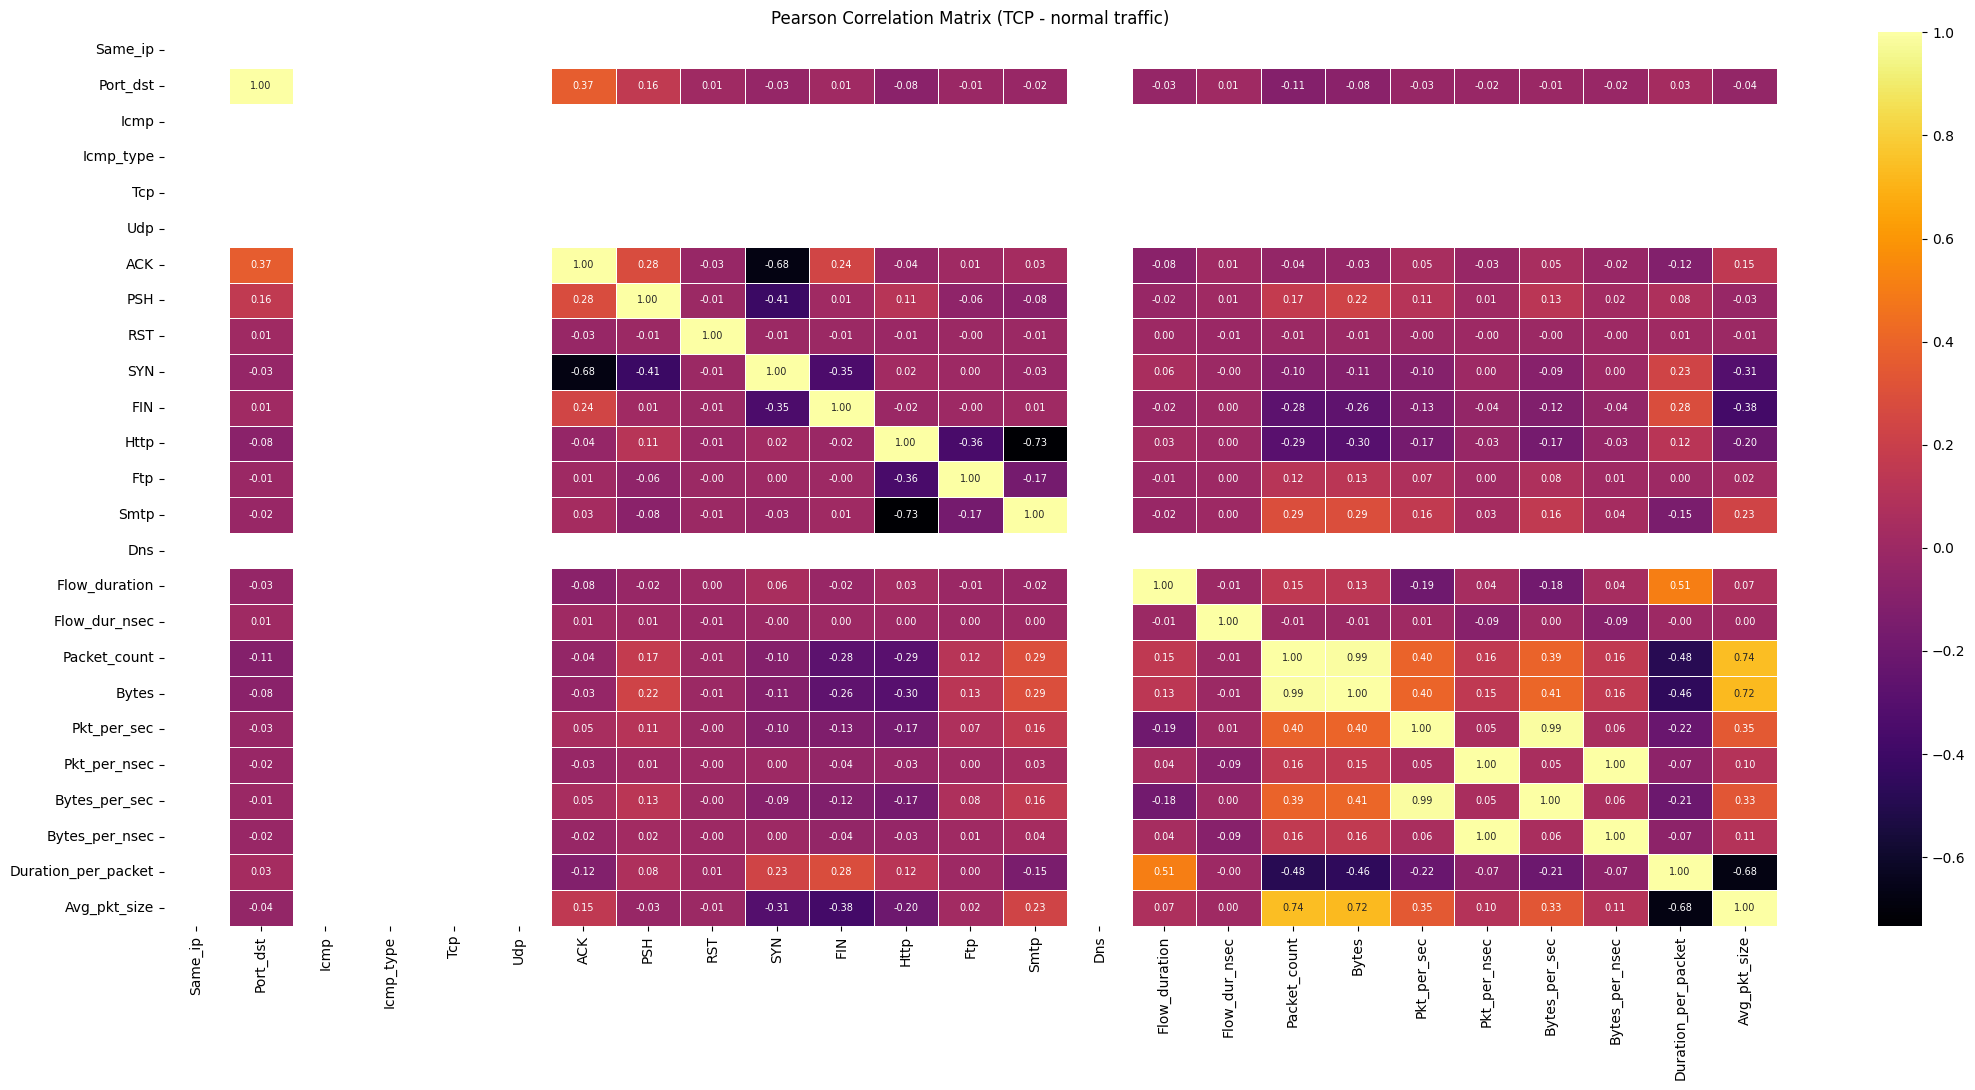

In [11]:
# one protocol split for the correlation analysis (TCP is richest)
df_corr = df_aug[df_aug['Ip_protocole'] == 'tcp'].copy()

# Exclude non-feature / metadata columns from the matrix
META_COLS = ['Timestamp','Ip_src','Ip_dst','Port_src','Ip_protocole',
             'Type_protocole','Icmp_code','Traffic','Attack_type']
corr_cols = [c for c in df_corr.columns if c not in META_COLS]

corr = df_corr[corr_cols].corr(method='pearson')

plt.figure(figsize=(22, 11))
sns.heatmap(
    corr,
    xticklabels=corr.columns,
    yticklabels=corr.columns,
    annot=True,
    fmt='.2f',
    linewidth=0.4,
    cmap='inferno',
    annot_kws={'size': 7},
)
plt.title('Pearson Correlation Matrix (TCP - normal traffic)')
plt.tight_layout()
plt.show()

In [12]:
# Programmatically list pairs with |r| > 0.90
threshold_corr = 0.90
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, row, round(upper.loc[row, col], 3))
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > threshold_corr
]

print(f'Pairs with |r| > {threshold_corr}:')
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f'  {a:20s} <-> {b:20s}  r={r}')

Pairs with |r| > 0.9:
  Bytes_per_nsec       <-> Pkt_per_nsec          r=0.997
  Bytes_per_sec        <-> Pkt_per_sec           r=0.992
  Bytes                <-> Packet_count          r=0.991


In [13]:
# ---- Drop confirmed redundant columns ----
#? After inspecting heatmap above.

# Dropping: Pkt_per_sec, Pkt_per_nsec, Packet_count


REDUNDANT_COLS = ['Pkt_per_sec', 'Pkt_per_nsec', 'Packet_count']

df_aug = df_aug.drop(columns=[c for c in REDUNDANT_COLS if c in df_aug.columns])
print('Remaining columns:', df_aug.columns.tolist())

Remaining columns: ['Timestamp', 'Ip_src', 'Ip_dst', 'Same_ip', 'Port_src', 'Port_dst', 'Ip_protocole', 'Type_protocole', 'Icmp', 'Icmp_code', 'Icmp_type', 'Tcp', 'Udp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Dns', 'Flow_duration', 'Flow_dur_nsec', 'Bytes', 'Bytes_per_sec', 'Bytes_per_nsec', 'Traffic', 'Attack_type', 'Duration_per_packet', 'Avg_pkt_size']


# Update feature lists to match dropped columns

After dropping redundant columns, `AUTOENCODER_FEATURES` must be updated locally
so that preprocessing uses the correct (smaller) feature set.
I did not **not** edit `pipeline.py` yet, I overrided the dict here for training,
then paste the final lists back into `pipeline.py` at the end.

In [64]:
# These are the feature lists AFTER dropping redundant columns

AUTOENCODER_FEATURES_V2 = {
    "icmp": [
        "Port_dst", "Icmp", "Icmp_type", "Tcp", "ACK", "PSH", "RST", "SYN",
        "FIN", "Http", "Smtp", "Ftp", "Udp", "Dns",
        "Flow_duration", "Same_ip",
        "Bytes_per_sec", 'Bytes_per_nsec', 'Bytes',
        "Duration_per_packet", "Avg_pkt_size",
    ],
    "tcp": [
        "Port_dst", "Icmp", "Tcp", "ACK", "PSH", "RST", "SYN", "FIN",
        "Http", "Ftp", "Smtp", "Udp",
        "Flow_duration", "Same_ip", "Bytes_per_sec",
        "Bytes_per_nsec", "Bytes",
        "Duration_per_packet", "Avg_pkt_size",
    ],
    "udp": [
        "Port_dst", "Icmp", "Tcp", "ACK", "PSH", "RST", "SYN", "FIN",
        "Http", "Ftp", "Smtp", "Udp", "Dns",
        "Flow_duration", "Packet_count", "Same_ip",
        "Bytes_per_sec", "Bytes_per_nsec", "Bytes",
        "Duration_per_packet", "Avg_pkt_size",
    ],
}

# columns to scale with StandardScaler (counters + ICMP type + engineered features)
STD_SCALE_COLS = {
    "icmp": ["Flow_duration", "Icmp_type", "Duration_per_packet", "Avg_pkt_size", "Port_dst", "Bytes"],
    "tcp":  ["Flow_duration", "Port_dst", "Duration_per_packet", "Avg_pkt_size", "Bytes"],
    "udp":  ["Flow_duration", "Port_dst", "Duration_per_packet", "Avg_pkt_size", "Bytes"],
}


# columns to scale with MinMaxScaler (rate features, flood attacks push these OOB)
MM_SCALE_COLS = {
    "icmp": ["Bytes_per_sec", "Bytes_per_nsec"],
    "tcp":  ["Bytes_per_sec", "Bytes_per_nsec"],
    "udp":  ["Bytes_per_sec", "Bytes_per_nsec"],
}

# These rate cols need to be added to the feature lists too
for proto in AUTOENCODER_FEATURES_V2:
    for col in MM_SCALE_COLS[proto]:
        if col not in AUTOENCODER_FEATURES_V2[proto]:
            AUTOENCODER_FEATURES_V2[proto].append(col)

print("Final feature counts:")
for proto, cols in AUTOENCODER_FEATURES_V2.items():
    print(f"  {proto.upper():4s}: {len(cols)} features -> {cols}")

Final feature counts:
  ICMP: 21 features -> ['Port_dst', 'Icmp', 'Icmp_type', 'Tcp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Smtp', 'Ftp', 'Udp', 'Dns', 'Flow_duration', 'Same_ip', 'Bytes_per_sec', 'Bytes_per_nsec', 'Bytes', 'Duration_per_packet', 'Avg_pkt_size']
  TCP : 19 features -> ['Port_dst', 'Icmp', 'Tcp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Udp', 'Flow_duration', 'Same_ip', 'Bytes_per_sec', 'Bytes_per_nsec', 'Bytes', 'Duration_per_packet', 'Avg_pkt_size']
  UDP : 21 features -> ['Port_dst', 'Icmp', 'Tcp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Udp', 'Dns', 'Flow_duration', 'Packet_count', 'Same_ip', 'Bytes_per_sec', 'Bytes_per_nsec', 'Bytes', 'Duration_per_packet', 'Avg_pkt_size']


# Preprocessing function

In [65]:
def preprocess_protocol(df, protocol):
    """
    Select features, fill missing values, filter ports, scale, return array + fitted scaler.
    Returns
    -------
    X       : np.ndarray float32
    scaler_std : fitted StandardScaler  (must be saved to JSON for RYU)
    scaler_mm  : fitted MinMaxScaler    (must be saved to JSON for RYU)
    """
    feature_cols = AUTOENCODER_FEATURES_V2[protocol]
    std_cols     = STD_SCALE_COLS[protocol]
    mm_cols      = MM_SCALE_COLS[protocol]


    feature_cols = [c for c in feature_cols if c in df.columns]
    std_cols     = [c for c in std_cols if c in df.columns]
    mm_cols      = [c for c in mm_cols if c in df.columns]

    X = df[feature_cols].copy()

    # Port filtering
    if 'Port_dst' in X.columns:
        X['Port_dst'] = X['Port_dst'].apply(filter_port)

    # fill any remaining NaNs with 0 (should already be clean, but safety net)
    X = X.fillna(0)

    # Standardization
    scaler_std = StandardScaler()
    X[std_cols] = scaler_std.fit_transform(X[std_cols].values)

    # Normalization
    scaler_mm = MinMaxScaler()
    X[mm_cols] = scaler_mm.fit_transform(X[mm_cols].values)

    return X.values.astype(np.float32), scaler_std, scaler_mm, feature_cols

# Split augmented data by protocol

In [66]:
df_icmp = df_aug[df_aug['Ip_protocole'] == 'icmp'].copy()
df_tcp  = df_aug[df_aug['Ip_protocole'] == 'tcp'].copy()
df_udp  = df_aug[df_aug['Ip_protocole'] == 'udp'].copy()

print(f'ICMP: {len(df_icmp):,} | TCP: {len(df_tcp):,} | UDP: {len(df_udp):,}')

ICMP: 25,800 | TCP: 46,091 | UDP: 32,460


# Autoencoder builder

In [67]:
def build_autoencoder(input_dim):
    """
    Symmetric dense autoencoder with fixed 6-neuron bottleneck.
    Architecture: input -> 30 -> 10 -> 6 -> 10 -> 30 -> input
    """
    inp        = Input(shape=(input_dim,))
    x          = Dense(30, activation='relu')(inp)
    x          = Dense(10, activation='relu')(x)
    bottleneck = Dense(6,  activation='relu')(x)
    x          = Dense(10, activation='relu')(bottleneck)
    x          = Dense(30, activation='relu')(x)
    out        = Dense(input_dim, activation='linear')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError())
    model.summary()
    return model

# Train one protocol

Threshold = `mean + 2 * std` of that distribution.
This is more principled than the 95th percentile (old one): it explicitly defines the
threshold as "2 standard deviations above what the model sees on normal traffic".

In [68]:
def train_and_save(df, protocol):
    print(f"\n{'='*50}")
    print(f"  {protocol.upper()} AUTOENCODER")
    print(f"{'='*50}")

    if len(df) < 30:
        print(f"Not enough samples ({len(df)}), skipping.")
        return None, None, None, None

    X, scaler_std, scaler_mm, used_features = preprocess_protocol(df, protocol)
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, shuffle=True)
    print(f"Train: {X_train.shape} | Test: {X_test.shape} | Features: {X_train.shape[1]}")

    model = build_autoencoder(X_train.shape[1])
    history = model.fit(
        X_train, X_train,
        epochs=50,
        batch_size=1600,
        validation_data=(X_test, X_test),
        verbose=1,
    )

    # compute RMSE on test set to pick threshold
    X_pred    = model.predict(X_test, verbose=0)
    mse_each  = np.mean(np.power(X_test - X_pred, 2), axis=1)   # shape (n_test,)
    rmse_each = np.sqrt(mse_each)

    threshold_mean2std = float(np.mean(rmse_each) + 2 * np.std(rmse_each))
    threshold_p95      = float(np.percentile(rmse_each, 95))

    print(f"\nThreshold (mean + 2*std):  {threshold_mean2std:.6f}")
    print(f"Threshold (95th pct):      {threshold_p95:.6f}")

    # plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'],     label='train loss')
    axes[0].plot(history.history['val_loss'], label='val loss')
    axes[0].set_title(f'{protocol.upper()} — Training loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
    axes[0].legend()

    axes[1].hist(rmse_each, bins=60, alpha=0.8, label='RMSE distribution')
    axes[1].axvline(threshold_mean2std, color='red',linestyle='--',
                    label=f'mean+2std = {threshold_mean2std:.4f}')
    axes[1].axvline(threshold_p95, color='orange', linestyle=':',
                    label=f'p95 = {threshold_p95:.4f}')
    axes[1].set_title(f'{protocol.upper()} - Reconstruction error on normal traffic')
    axes[1].set_xlabel('RMSE'); axes[1].legend()

    plt.tight_layout()
    plt.show()

    # save model only
    model.save(f"../ryu-controller/{protocol}.h5")
    print(f"Saved {protocol}.h5")

    return threshold_mean2std, scaler_std, scaler_mm, used_features

# Start Traingin

### ICMP


  ICMP AUTOENCODER
Train: (20640, 21) | Test: (5160, 21) | Features: 21


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 30)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 21)             │           651 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,087 (8.15 KB)

 Trainable params: 2,087 (8.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5164 - val_loss: 0.4944
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4880 - val_loss: 0.4537
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4341 - val_loss: 0.3929
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3749 - val_loss: 0.3375
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3210 - val_loss: 0.2835
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2612 - val_loss: 0.2181
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2029 - val_loss: 0.1747
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1706 - val_loss: 0.1511
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1476 - val_loss: 0.1295
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1258 - val_loss: 0.1089
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1049 - val_loss: 0.0893
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0857 - val_l

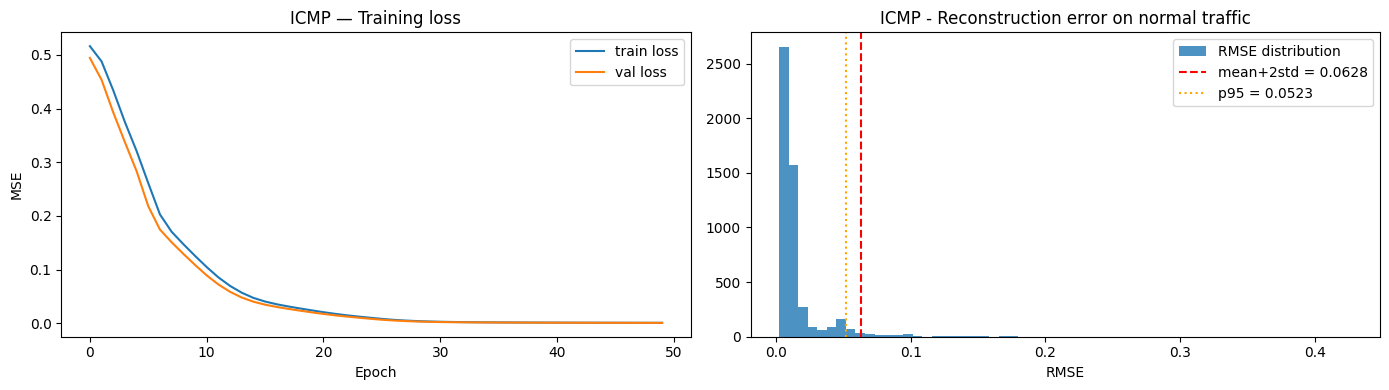

Saved icmp.h5


In [79]:
threshold_icmp, scaler_std_icmp, scaler_mm_icmp, features_icmp = train_and_save(df_icmp, 'icmp')

### TCP


  TCP AUTOENCODER
Train: (36872, 19) | Test: (9219, 19) | Features: 19


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 30)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 19)             │           589 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,965 (7.68 KB)

 Trainable params: 1,965 (7.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4002 - val_loss: 0.3481
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3068 - val_loss: 0.2628
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2305 - val_loss: 0.1959
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1759 - val_loss: 0.1582
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1480 - val_loss: 0.1386
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1317 - val_loss: 0.1240
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1161 - val_loss: 0.1066
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0976 - val_loss: 0.0872
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0788 - val_loss: 0.0704
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0649 - val_loss: 0.0601
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0568 - val_loss: 0.0538
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0509 - val_lo

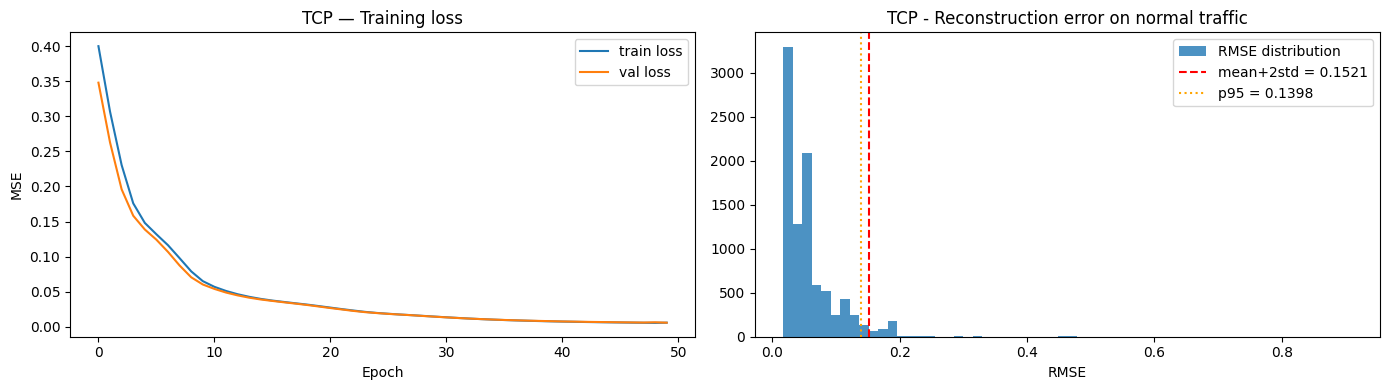

Saved tcp.h5


In [69]:
threshold_tcp, scaler_std_tcp, scaler_mm_tcp, features_tcp = train_and_save(df_tcp, 'tcp')

### UDP


  UDP AUTOENCODER
Train: (25968, 20) | Test: (6492, 20) | Features: 20


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 20)             │           620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,026 (7.91 KB)

 Trainable params: 2,026 (7.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6063 - val_loss: 0.5310
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5640 - val_loss: 0.4841
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4963 - val_loss: 0.3941
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3815 - val_loss: 0.2665
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2541 - val_loss: 0.1596
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1585 - val_loss: 0.0887
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0948 - val_loss: 0.0502
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0590 - val_loss: 0.0277
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0324 - val_loss: 0.0146
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0177 - val_loss: 0.0084
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0111 - val_loss: 0.0056
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084 - val_l

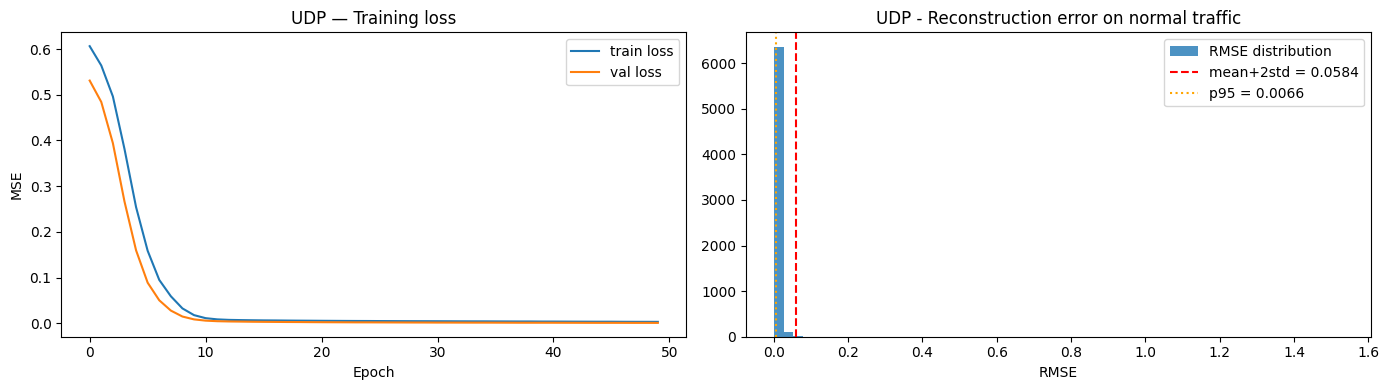

Saved udp.h5


In [42]:
threshold_udp, scaler_std_udp, scaler_mm_udp, features_udp = train_and_save(df_udp, 'udp')

# Sanity check 
Load a small sample of attack traffic you collected (even 30 - 60 rows is enough),
run it through the trained model, and verify RMSE exceeds the threshold.
If it doesn't, lower the threshold manually or retrain with more epochs.
I know, it is tricky to get it right on the first try, but you can iterate quickly with a small test set.

In [ ]:
def validate_against_attack(attack_csv_path, protocol, model_path,
                             scaler_std, scaler_mm, threshold, used_features):
    """Quick sanity check: does attack data produce RMSE above threshold?"""
    from keras.models import load_model

    df_atk = pd.read_csv(attack_csv_path)
    df_atk = df_atk[df_atk['Ip_protocole'] == protocol].copy()

    if len(df_atk) < 5:
        print(f'Not enough {protocol} rows in {attack_csv_path}, skipping.')
        return
    
    df_atk['Duration_per_packet'] = df_atk['Flow_duration'] / (df_atk['Packet_count'] + 1e-6)
    df_atk['Avg_pkt_size'] = (
        df_atk['Bytes_per_sec'] / (df_atk['Pkt_per_sec'] + 1e-6)
    ).replace([np.inf, -np.inf], 0)

    std_cols = STD_SCALE_COLS[protocol]
    mm_cols  = MM_SCALE_COLS[protocol]

    # Use only columns that exist
    feat_cols = [c for c in used_features if c in df_atk.columns]
    std_cols  = [c for c in std_cols if c in df_atk.columns]
    mm_cols   = [c for c in mm_cols  if c in df_atk.columns]

    X_atk = df_atk[feat_cols].fillna(0).copy()
    if 'Port_dst' in X_atk.columns:
        X_atk['Port_dst'] = X_atk['Port_dst'].apply(filter_port)

    X_atk[std_cols] = scaler_std.transform(X_atk[std_cols].values)
    X_atk[mm_cols]  = scaler_mm.transform(X_atk[mm_cols].values)
    X_atk = X_atk.values.astype(np.float32)

    model    = load_model(model_path)
    X_pred   = model.predict(X_atk, verbose=0)
    mse_each = np.mean(np.power(X_atk - X_pred, 2), axis=1)
    rmse_val = float(np.mean(np.sqrt(mse_each)))

    status = '[DETECTED]' if rmse_val > threshold else '[MISSED] (lower threshold)'
    print(f'[{protocol.upper()}] Attack RMSE: {rmse_val:.6f} | Threshold: {threshold:.6f} | {status}')

# ── Usage: point to any CSV that has labelled attack rows ──────────────────
validate_against_attack(
    '../ryu-controller/traffic_ICMP_flood.csv',
    'icmp',
    '../ryu-controller/icmp.h5',
    scaler_std_icmp, scaler_mm_icmp,
    threshold_icmp, features_icmp,
)

C:\Users\moulo\AppData\Local\Temp\ipykernel_2496\669211032.py:6: DtypeWarning: Columns (0: Type_protocole) have mixed types. Specify dtype option on import or set low_memory=False.
  df_atk = pd.read_csv(attack_csv_path)


[ICMP] Attack RMSE: 0.190984 | Threshold: 0.145573 | [DETECTED]


Here I converted the models to .onnx for compatibility with RYU during runtime. `h5` files are used by keras, which comes with Tensorflow, but since I am using python 3.8 for RYU, there will be compatibility issues with Tensorflow, so I will use ONNX format which is more universal and can be used with different frameworks

In [80]:
import tf2onnx, onnx
from keras.models import load_model

for proto in ("icmp", "tcp", "udp"):
    m = load_model(f"../ryu-controller/{proto}.h5")
    onnx_model, _ = tf2onnx.convert.from_keras(m, opset=13)
    onnx.save(onnx_model, f"../ryu-controller/{proto}.onnx")
    print(f"Saved {proto}.onnx")

Saved icmp.onnx
Saved tcp.onnx
Saved udp.onnx


# Saving Scalers

Pickling is the standard way of saving. But the the issue is it saves numpy arrays as well, and I am using python 3.8 (venv) for RYU, so this will break the code. i kept only because it is the standard way.
In order to solve that isee, I saved the scalers manually as json files, so i can skip saving the numpy arrays. I will load these json files in RYU and create the scalers there.

In [24]:

for protocol in ('icmp', 'tcp', 'udp'):
    with open(f'../ryu-controller/std_{protocol}.pkl', 'wb') as f:
        pickle.dump(locals().get(f'scaler_std_{protocol}'), f)

    with open(f'../ryu-controller/mm_{protocol}.pkl', 'wb') as f:
        pickle.dump(locals().get(f'scaler_mm_{protocol}'), f)

    print(f'Saved std_{protocol}.pkl and mm_{protocol}.pkl')

Saved std_icmp.pkl and mm_icmp.pkl
Saved std_tcp.pkl and mm_tcp.pkl
Saved std_udp.pkl and mm_udp.pkl


In [73]:
def save_scaler_json(scaler, path):
    """Serialise a fitted StandardScaler or MinMaxScaler to JSON."""
    if isinstance(scaler, StandardScaler):
        data = {
            'type':           'standard',
            'mean':           scaler.mean_.tolist(),
            'scale':          scaler.scale_.tolist(),
            'var':            scaler.var_.tolist(),
            'n_samples_seen': int(scaler.n_samples_seen_),
        }
    elif isinstance(scaler, MinMaxScaler):
        data = {
            'type':           'minmax',
            'scale':          scaler.scale_.tolist(),
            'min':            scaler.min_.tolist(),
            'data_min':       scaler.data_min_.tolist(),
            'data_max':       scaler.data_max_.tolist(),
            'data_range':     scaler.data_range_.tolist(),
            'n_samples_seen': int(scaler.n_samples_seen_),
        }
    else:
        raise ValueError(f'Unknown scaler type: {type(scaler)}')
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)
    print(f'Saved {path}')

scalers = {
    'icmp': (scaler_std_icmp, scaler_mm_icmp),
    'tcp':  (scaler_std_tcp,  scaler_mm_tcp),
    'udp':  (scaler_std_udp,  scaler_mm_udp),
}

for proto, (s_std, s_mm) in scalers.items():
    save_scaler_json(s_std, f'../ryu-controller/std_{proto}.json')
    save_scaler_json(s_mm,  f'../ryu-controller/mm_{proto}.json')


Saved ../ryu-controller/std_icmp.json
Saved ../ryu-controller/mm_icmp.json
Saved ../ryu-controller/std_tcp.json
Saved ../ryu-controller/mm_tcp.json
Saved ../ryu-controller/std_udp.json
Saved ../ryu-controller/mm_udp.json


# Save final feature lists to JSON (for monitor.py)

In [75]:
feature_registry = {
    'icmp': features_icmp,
    'tcp':  features_tcp,
    'udp':  features_udp,
}
with open('../ryu-controller/autoencoder_features.json', 'w') as f:
    json.dump(feature_registry, f, indent=2)
print('Saved autoencoder_features.json')

Saved autoencoder_features.json


# Print final thresholds to update in monitor.py

In [81]:
print('\nUpdate these constants in monitor.py:')
print(f'THRESHOLD_ICMP = {threshold_icmp:.6f}')
print(f'THRESHOLD_TCP  = {threshold_tcp:.6f}')
print(f'THRESHOLD_UDP  = {threshold_udp:.6f}')
print()
print('Update AUTOENCODER_FEATURES in pipeline.py:')
for proto, cols in AUTOENCODER_FEATURES_V2.items():
    print(f'  {proto!r}: {cols},')

print('Update AUTOENCODER_STD_COLS in pipeline.py:')
for proto, cols in STD_SCALE_COLS.items():
    print(f'  {proto!r}: {cols}')
    
print('Update AUTOENCODER_MM_COLS in pipeline.py:')
for proto, cols in MM_SCALE_COLS.items():
    print(f'  {proto!r}: {cols}')


Update these constants in monitor.py:
THRESHOLD_ICMP = 0.062839
THRESHOLD_TCP  = 0.152146
THRESHOLD_UDP  = 0.058415

Update AUTOENCODER_FEATURES in pipeline.py:
  'icmp': ['Port_dst', 'Icmp', 'Icmp_type', 'Tcp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Smtp', 'Ftp', 'Udp', 'Dns', 'Flow_duration', 'Same_ip', 'Bytes_per_sec', 'Bytes_per_nsec', 'Bytes', 'Duration_per_packet', 'Avg_pkt_size'],
  'tcp': ['Port_dst', 'Icmp', 'Tcp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Udp', 'Flow_duration', 'Same_ip', 'Bytes_per_sec', 'Bytes_per_nsec', 'Bytes', 'Duration_per_packet', 'Avg_pkt_size'],
  'udp': ['Port_dst', 'Icmp', 'Tcp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Udp', 'Dns', 'Flow_duration', 'Packet_count', 'Same_ip', 'Bytes_per_sec', 'Bytes_per_nsec', 'Bytes', 'Duration_per_packet', 'Avg_pkt_size'],
Update AUTOENCODER_STD_COLS in pipeline.py:
  'icmp': ['Flow_duration', 'Icmp_type', 'Duration_per_packet', 'Avg_pkt_size', 'Port_dst', 'Bytes']
  'tcp'